In [13]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# IMPORTANDO DADOS

In [14]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_pitch,target_wz,target_wy,target_az,target_wx,target_e,target_ay,target_tmp,target_yaw,target_ax,target_roll,static
0,0.0,161.399,-0.28498,0.02387,-3.098666,-0.41792,0.0,-8.810932,46.5,359.904,2.970150,-18.605,False
1,0.1,161.399,-0.29589,0.11780,-3.159712,-0.18404,0.0,-8.850933,46.6,359.905,2.973337,-18.604,False
2,0.2,161.398,-0.10334,0.07233,-3.177168,0.17382,0.0,-8.815835,46.8,359.903,2.926363,-18.604,False
3,0.3,161.398,0.33386,0.02622,-3.140011,-0.10057,0.0,-8.793250,46.8,359.902,2.931374,-18.603,False
4,0.4,161.398,0.47356,0.12890,-3.119544,-0.10119,0.0,-8.823877,46.6,359.902,2.953753,-18.603,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,324.5,161.305,0.52779,-0.15544,-3.103216,0.04977,0.0,-8.800301,51.0,358.905,2.997177,-18.502,True
3247,324.6,161.308,-0.02845,0.25141,-3.062578,0.01336,0.0,-8.824024,50.9,358.904,3.028117,-18.500,True
3248,324.7,161.308,0.20303,0.00054,-3.067461,0.33231,0.0,-8.819101,51.0,358.903,2.948811,-18.500,True
3249,324.8,161.311,-0.22021,-0.00122,-3.123771,0.15968,0.0,-8.854061,50.9,358.903,3.003747,-18.501,True


In [15]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_pitch,ref_wz,ref_wy,ref_la_pos_mon_d,ref_wx,ref_az,ref_ay,ref_q1,ref_sample_time,ref_q0,ref_q2,ref_q3,ref_yaw,ref_ax,ref_roll,static
0,0.0,15.126086,0.000987,-0.011992,-0.2845,0.010285,3.403,-8.813,0.8174,705000000.0,0.5608,0.07407,-0.1088,-0.055720,2.554,111.096516,False
1,0.1,15.126086,0.020054,-0.002231,-0.2893,0.004733,3.403,-8.813,0.8174,805000000.0,0.5608,0.07406,-0.1088,-0.056173,2.553,111.096516,False
2,0.2,15.126086,0.004792,0.004034,-0.2941,0.011591,3.403,-8.813,0.8174,905000000.0,0.5608,0.07406,-0.1088,-0.055955,2.554,111.096516,False
3,0.3,15.126086,0.001441,-0.003922,-0.2989,0.018065,3.403,-8.813,0.8174,5000000.0,0.5608,0.07405,-0.1088,-0.056608,2.553,111.096516,False
4,0.4,15.126086,-0.009912,-0.003138,-0.3037,0.005427,3.403,-8.813,0.8174,105000000.0,0.5608,0.07405,-0.1088,-0.056826,2.554,111.096516,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,324.5,23.388137,0.002860,-0.138312,10.0000,0.063369,3.375,-8.817,0.7375,205000000.0,0.3690,-0.35000,-0.4442,-66.864175,2.576,111.268404,True
3247,324.6,23.393867,-0.002476,-0.145703,10.0000,0.073339,3.375,-8.817,0.7375,305000000.0,0.3689,-0.35010,-0.4443,-66.921470,2.576,111.268404,True
3248,324.7,23.399596,0.005964,-0.144443,10.0000,0.087261,3.375,-8.817,0.7375,405000000.0,0.3688,-0.35020,-0.4444,-66.921470,2.576,111.268404,True
3249,324.8,23.399596,-0.002044,-0.145589,10.0000,0.092991,3.375,-8.817,0.7375,505000000.0,0.3687,-0.35030,-0.4444,-66.921470,2.576,111.268404,True


In [16]:
df = pd.merge_asof(df_target, df_ref, on='time', by='static', direction='nearest')
df

,time,target_pitch,target_wz,target_wy,target_az,target_wx,target_e,target_ay,target_tmp,target_yaw,target_ax,target_roll,static,ref_pitch,ref_wz,ref_wy,ref_la_pos_mon_d,ref_wx,ref_az,ref_ay,ref_q1,ref_sample_time,ref_q0,ref_q2,ref_q3,ref_yaw,ref_ax,ref_roll
0,0.0,161.399,-0.28498,0.02387,-3.098666,-0.41792,0.0,-8.810932,46.5,359.904,2.970150,-18.605,False,15.126086,0.000987,-0.011992,-0.2845,0.010285,3.403,-8.813,0.8174,705000000.0,0.5608,0.07407,-0.1088,-0.055720,2.554,111.096516
1,0.1,161.399,-0.29589,0.11780,-3.159712,-0.18404,0.0,-8.850933,46.6,359.905,2.973337,-18.604,False,15.126086,0.020054,-0.002231,-0.2893,0.004733,3.403,-8.813,0.8174,805000000.0,0.5608,0.07406,-0.1088,-0.056173,2.553,111.096516
2,0.2,161.398,-0.10334,0.07233,-3.177168,0.17382,0.0,-8.815835,46.8,359.903,2.926363,-18.604,False,15.126086,0.004792,0.004034,-0.2941,0.011591,3.403,-8.813,0.8174,905000000.0,0.5608,0.07406,-0.1088,-0.055955,2.554,111.096516
3,0.3,161.398,0.33386,0.02622,-3.140011,-0.10057,0.0,-8.793250,46.8,359.902,2.931374,-18.603,False,15.126086,0.001441,-0.003922,-0.2989,0.018065,3.403,-8.813,0.8174,5000000.0,0.5608,0.07405,-0.1088,-0.056608,2.553,111.096516
4,0.4,161.398,0.47356,0.12890,-3.119544,-0.10119,0.0,-8.823877,46.6,359.902,2.953753,-18.603,False,15.126086,-0.009912,-0.003138,-0.3037,0.005427,3.403,-8.813,0.8174,105000000.0,0.5608,0.07405,-0.1088,-0.056826,2.554,111.096516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,324.5,161.305,0.52779,-0.15544,-3.103216,0.04977,0.0,-8.800301,51.0,358.905,2.997177,-18.502,True,23.388137,0.002860,-0.138312,10.0000,0.063369,3.375,-8.817,0.7375,205000000.0,0.3690,-0.35000,-0.4442,-66.864175,2.576,111.268404
3247,324.6,161.308,-0.02845,0.25141,-3.062578,0.01336,0.0,-8.824024,50.9,358.904,3.028117,-18.500,True,23.393867,-0.002476,-0.145703,10.0000,0.073339,3.375,-8.817,0.7375,305000000.0,0.3689,-0.35010,-0.4443,-66.921470,2.576,111.268404
3248,324.7,161.308,0.20303,0.00054,-3.067461,0.33231,0.0,-8.819101,51.0,358.903,2.948811,-18.500,True,23.399596,0.005964,-0.144443,10.0000,0.087261,3.375,-8.817,0.7375,405000000.0,0.3688,-0.35020,-0.4444,-66.921470,2.576,111.268404
3249,324.8,161.311,-0.22021,-0.00122,-3.123771,0.15968,0.0,-8.854061,50.9,358.903,3.003747,-18.501,True,23.399596,-0.002044,-0.145589,10.0000,0.092991,3.375,-8.817,0.7375,505000000.0,0.3687,-0.35030,-0.4444,-66.921470,2.576,111.268404


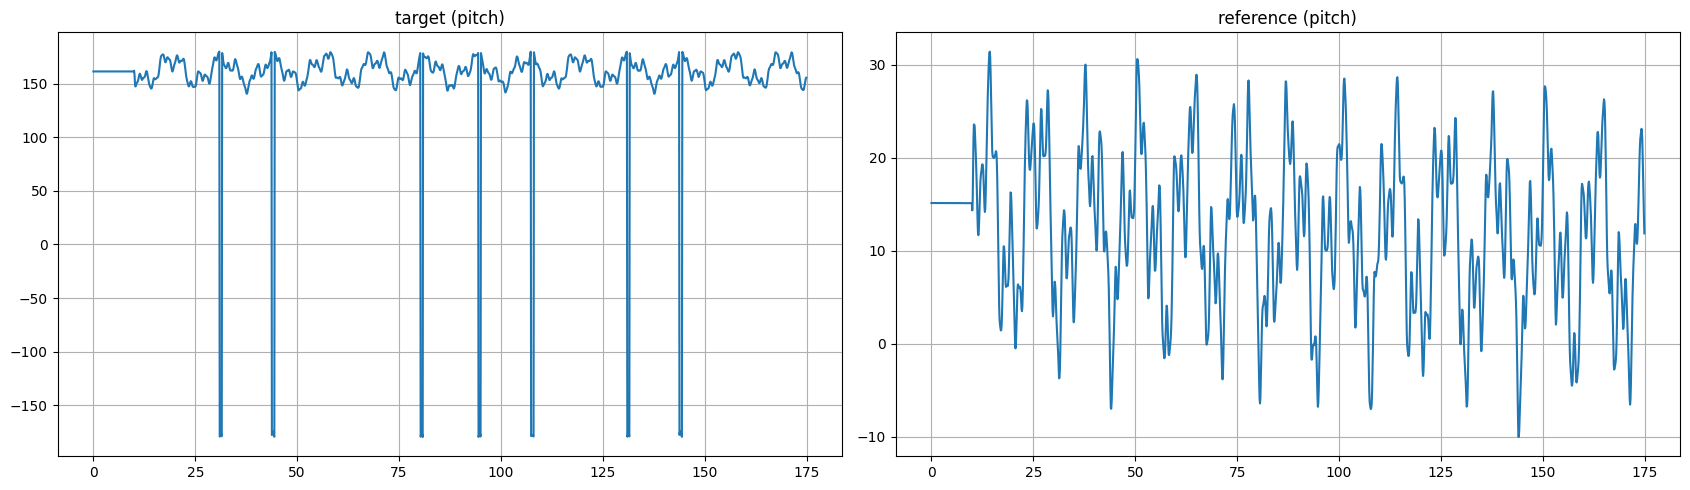

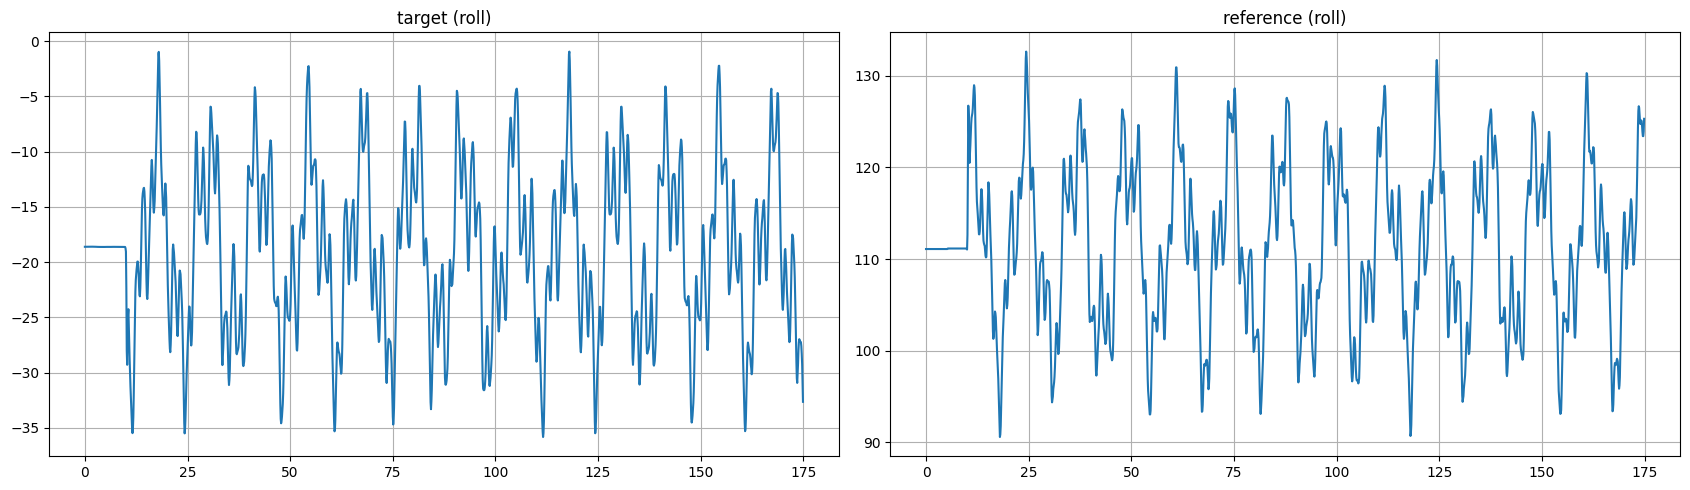

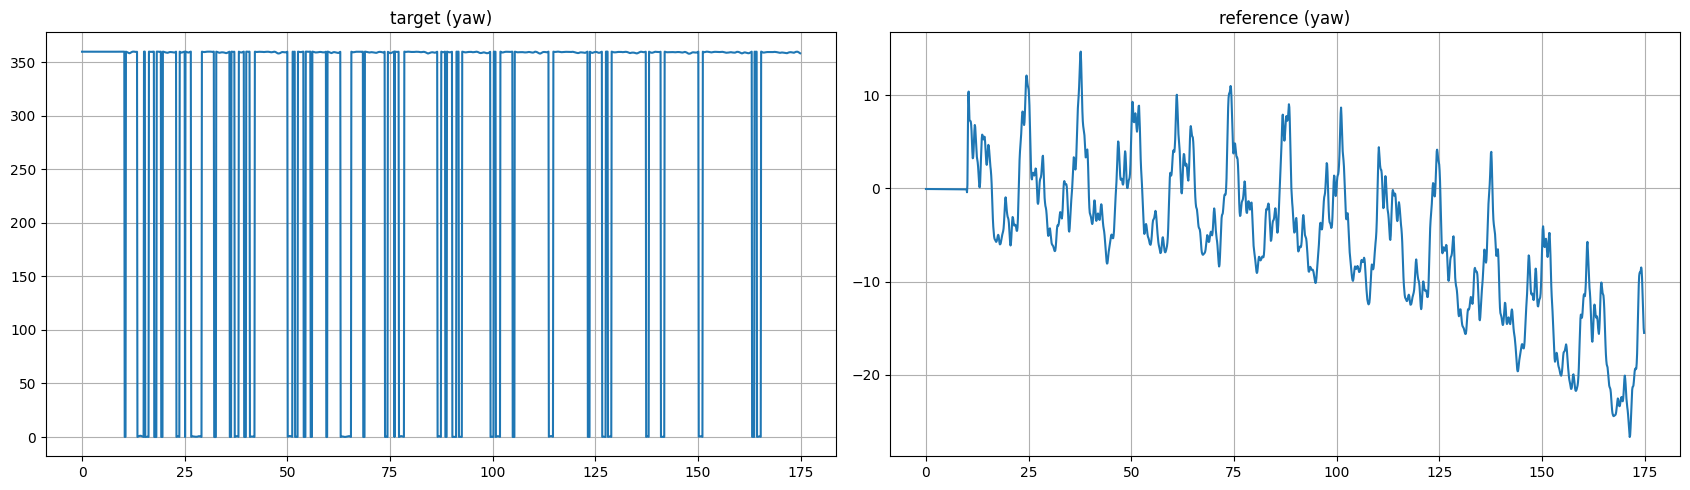

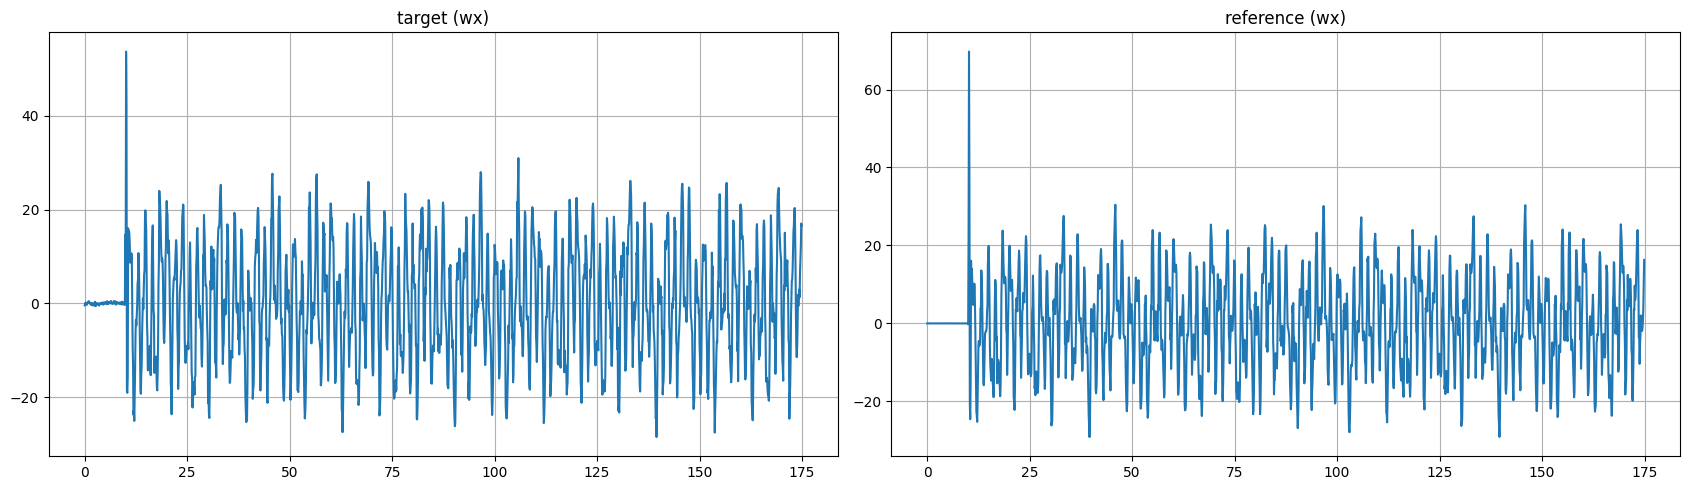

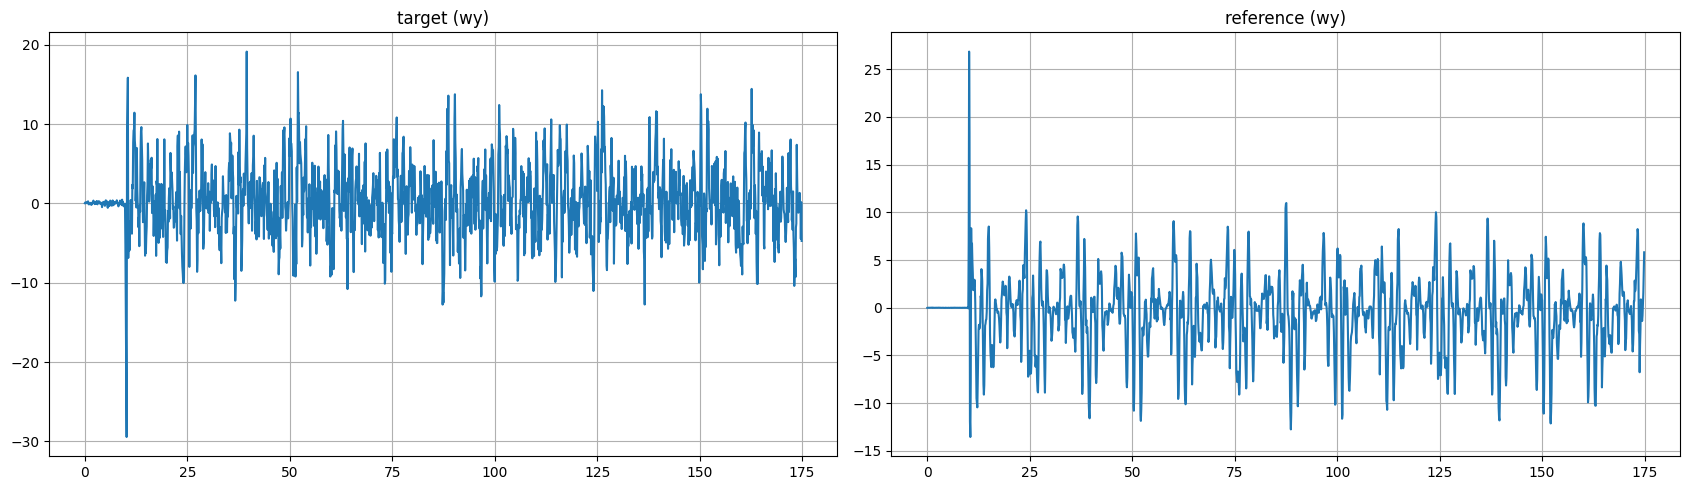

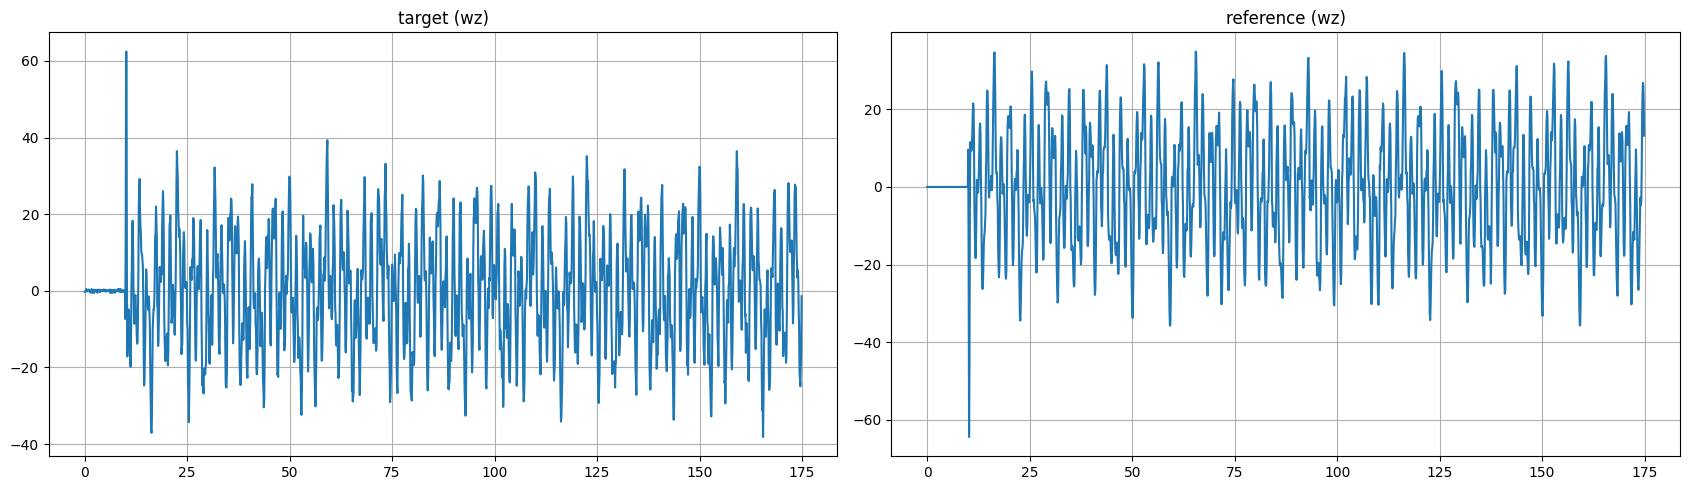

In [17]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df.loc[~df.static][f'target_{var}'], 
        f'reference ({var})': df.loc[~df.static][f'ref_{var}']
    }, time=df.loc[~df.static].time, figsize=(17, 5))

# REMOVENDO A BARRIGUINHA

In [ ]:
def clearBarriguinha(df, undesired=(45, 80)):
    # Desempacota os limites do intervalo
    start_time, end_time = undesired
    
    # 1. Pega os dados ANTES da barriguinha
    df_before = df[df['time'] < start_time].copy()
    
    # 2. Pega os dados DEPOIS da barriguinha
    df_after = df[df['time'] > end_time].copy()
    
    # 3. Calcula o tamanho do gap (duração da barriguinha)
    gap_duration = end_time - start_time
    
    # 4. Desloca o tempo dos dados 'depois' para trás, fechando o buraco
    df_after['time'] = df_after['time'] - gap_duration
    
    # 5. Junta os dois pedaços e reseta o índice
    df_cleaned = pd.concat([df_before, df_after]).reset_index(drop=True)
    
    return df_cleaned



test = json.loads(open('../info.json', 'r', encoding='utf-8').read())['target']['test']
axis = json.loads(open('../info.json', 'r', encoding='utf-8').read())['target']['axis']
interval = json.loads(open(f'files/test{test}/rolling_{axis}/info.json', 'r', encoding='utf-8').read()).get('belly')
print(interval)

df = clearBarriguinha(df, interval)
df.head()

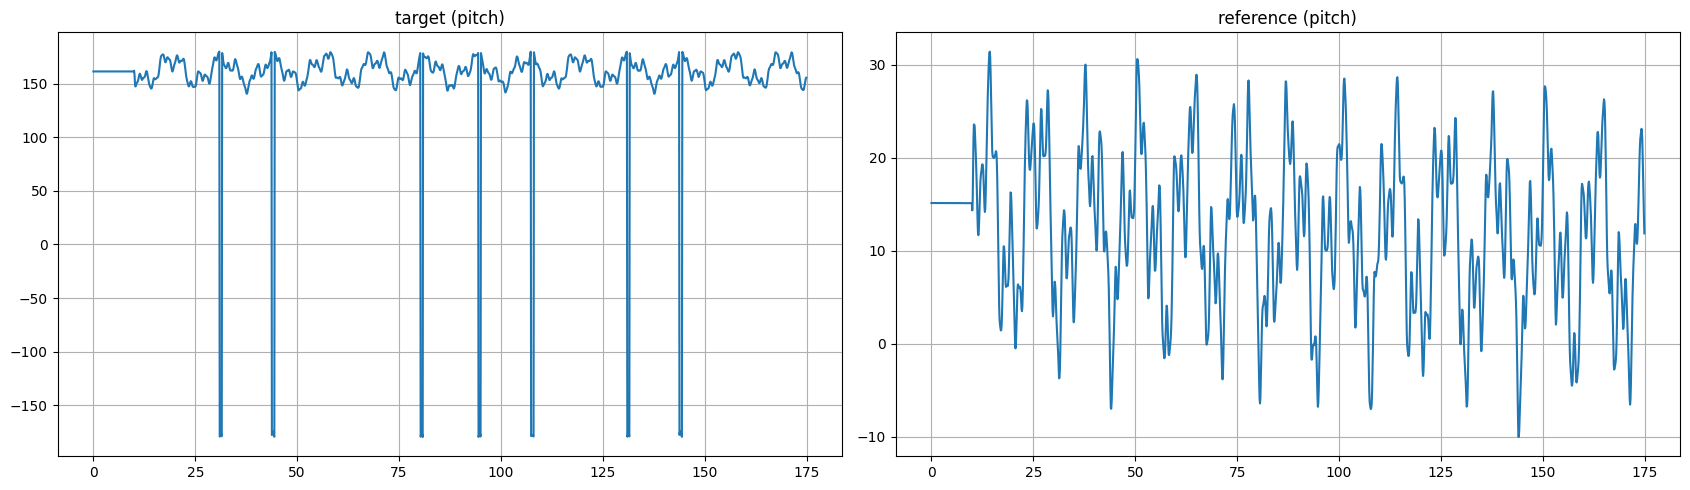

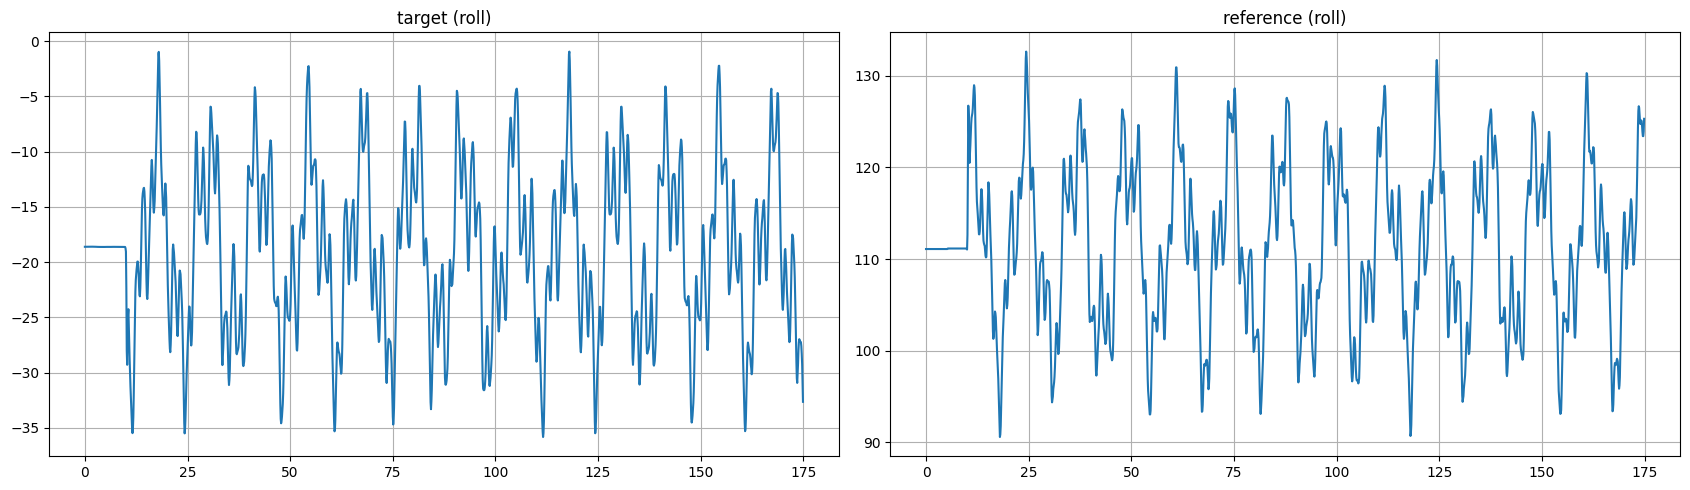

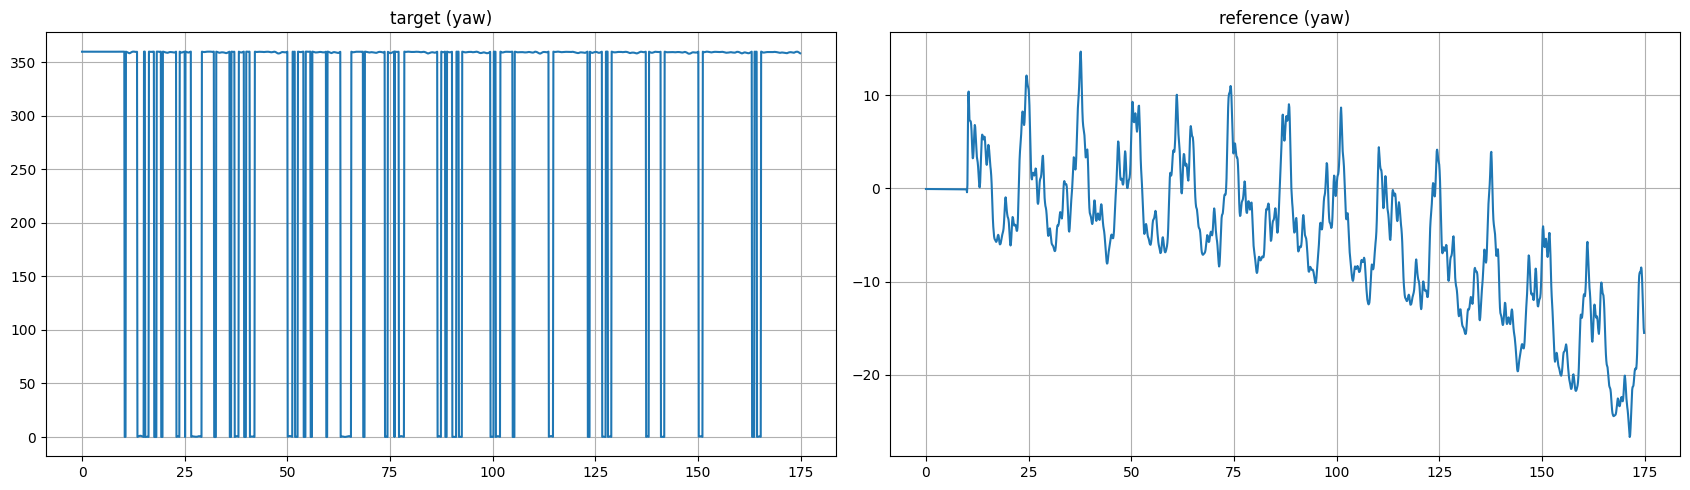

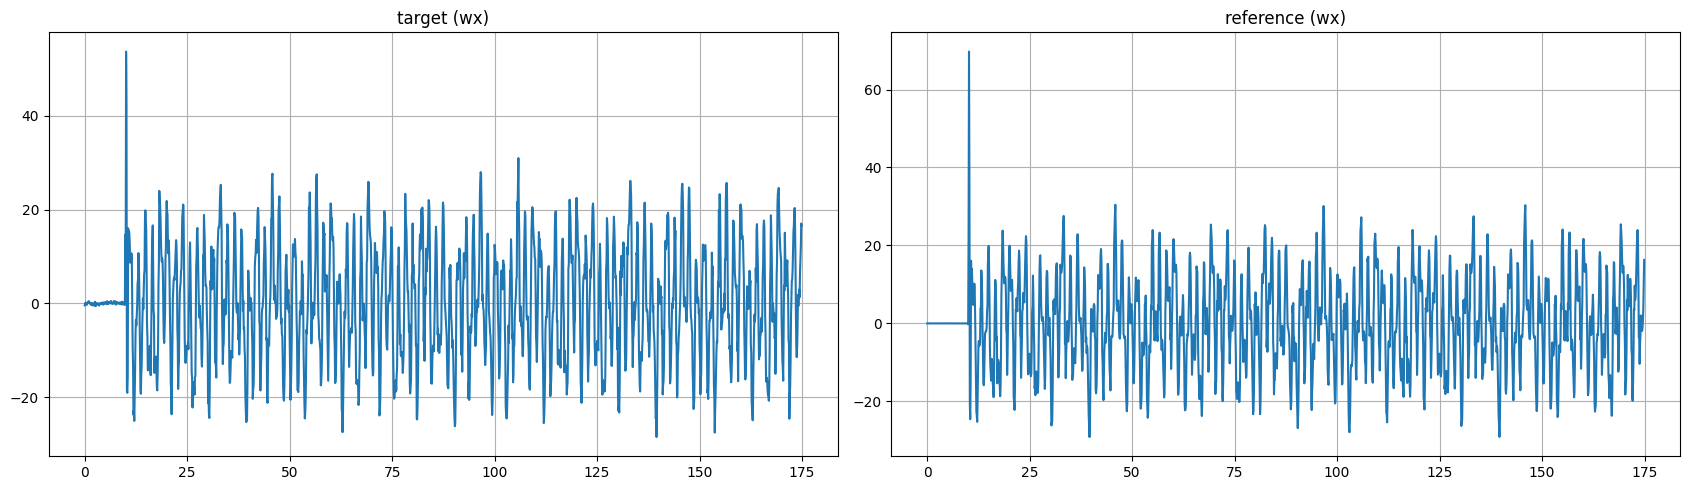

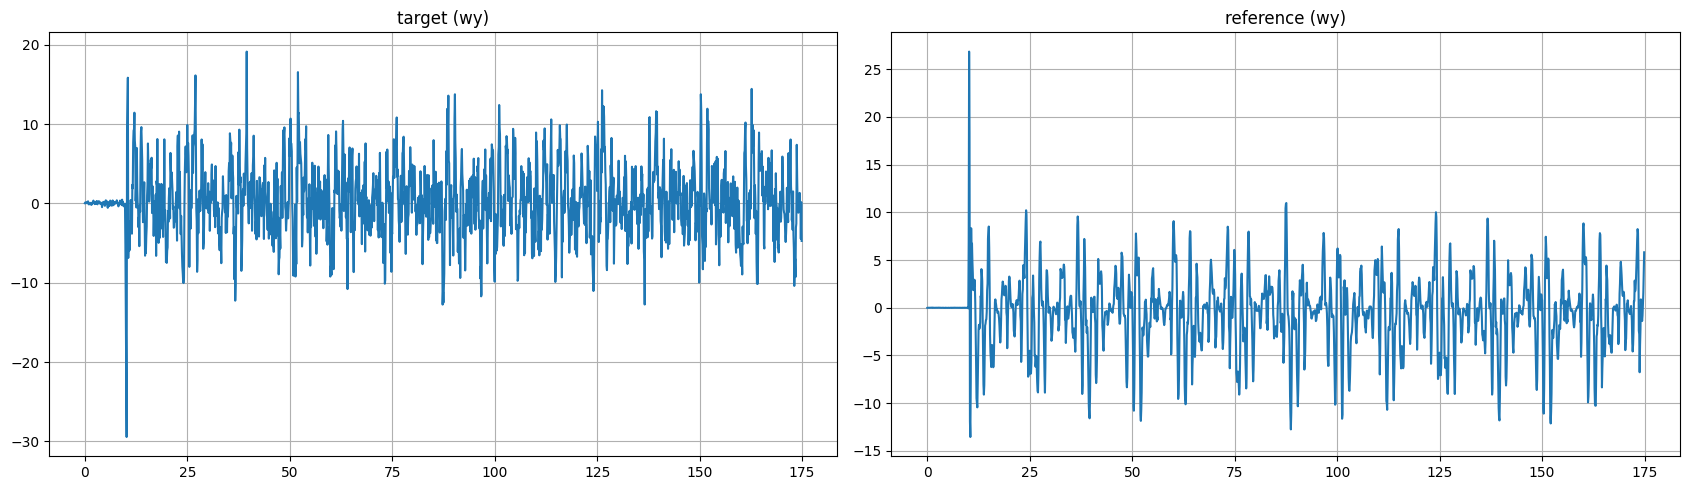

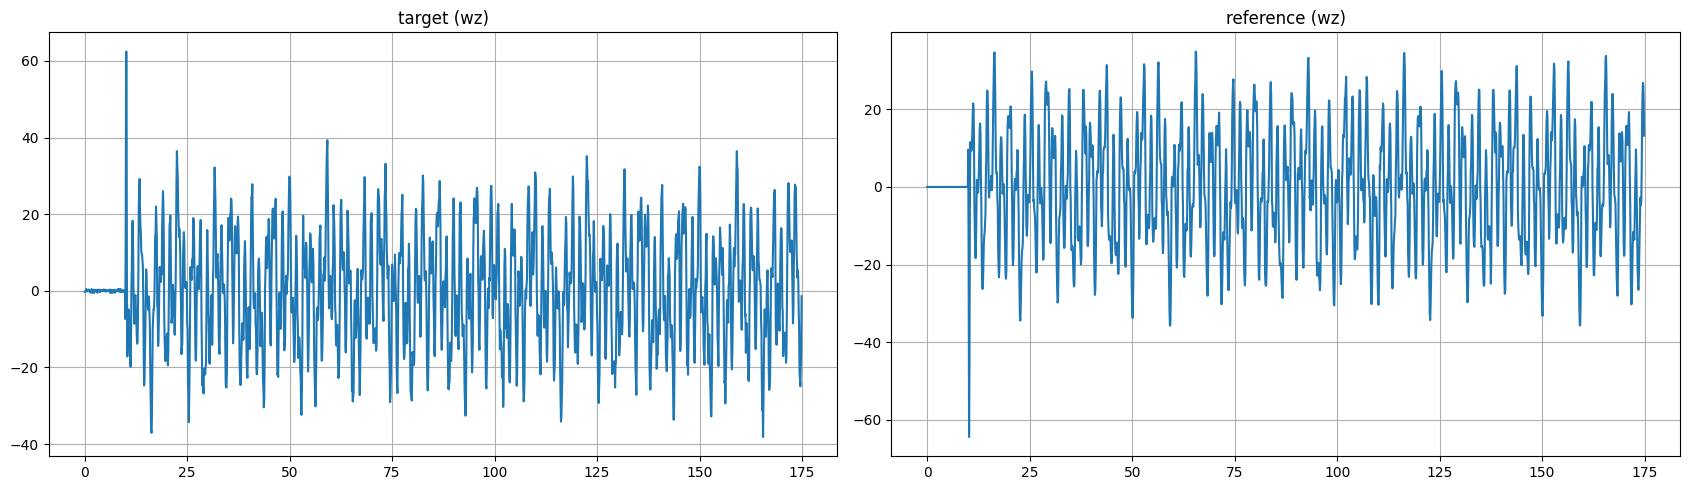

In [18]:
for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df.loc[~df.static][f'target_{var}'], 
        f'reference ({var})': df.loc[~df.static][f'ref_{var}']
    }, time=df.loc[~df.static].time, figsize=(17, 5))

# SALVANDO DADOS

In [19]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)